In [1]:
# ============================================================
# Task 2: Fashion-MNIST Classification Project
# Step 1: Test basic Python libraries
# ============================================================

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Basic libraries work successfully.")

Python version: 3.11.15 (main, Mar 11 2026, 17:14:47) [Clang 20.1.8 ]
NumPy version: 2.4.6
Pandas version: 3.0.3
Basic libraries work successfully.


In [2]:
# ============================================================
# Step 2: Test TensorFlow installation
# ============================================================

try:
    import tensorflow as tf
    print("TensorFlow version:", tf.__version__)
    print("TensorFlow imported successfully.")
except ImportError as e:
    print("TensorFlow is not installed yet.")
    print(e)

TensorFlow version: 2.21.0
TensorFlow imported successfully.


In [3]:
# ============================================================
# Step 3: Import all required project libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    accuracy_score
)

print("All project libraries imported successfully.")

All project libraries imported successfully.


In [4]:
# ============================================================
# Step 4: Create a folder to save result figures and tables
# ============================================================

results_dir = "results"

if not os.path.exists(results_dir):
    os.makedirs(results_dir)

print(f"Results folder ready: {results_dir}")

Results folder ready: results


In [5]:
# ============================================================
# Step 5: Load the Fashion-MNIST dataset
# ============================================================

# Fashion-MNIST is already included in TensorFlow/Keras
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Class names according to Fashion-MNIST
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)
print("Number of classes:", len(class_names))

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Number of classes: 10


In [6]:
# ============================================================
# Step 6: Create a dataset summary table
# ============================================================

dataset_summary = pd.DataFrame({
    "Dataset part": ["Training set", "Test set", "Total"],
    "Number of images": [x_train.shape[0], x_test.shape[0], x_train.shape[0] + x_test.shape[0]],
    "Image size": ["28 x 28 pixels", "28 x 28 pixels", "28 x 28 pixels"],
    "Color format": ["Grayscale", "Grayscale", "Grayscale"],
    "Number of classes": [len(class_names), len(class_names), len(class_names)]
})

dataset_summary

,Dataset part,Number of images,Image size,Color format,Number of classes
0,Training set,60000,28 x 28 pixels,Grayscale,10
1,Test set,10000,28 x 28 pixels,Grayscale,10
2,Total,70000,28 x 28 pixels,Grayscale,10


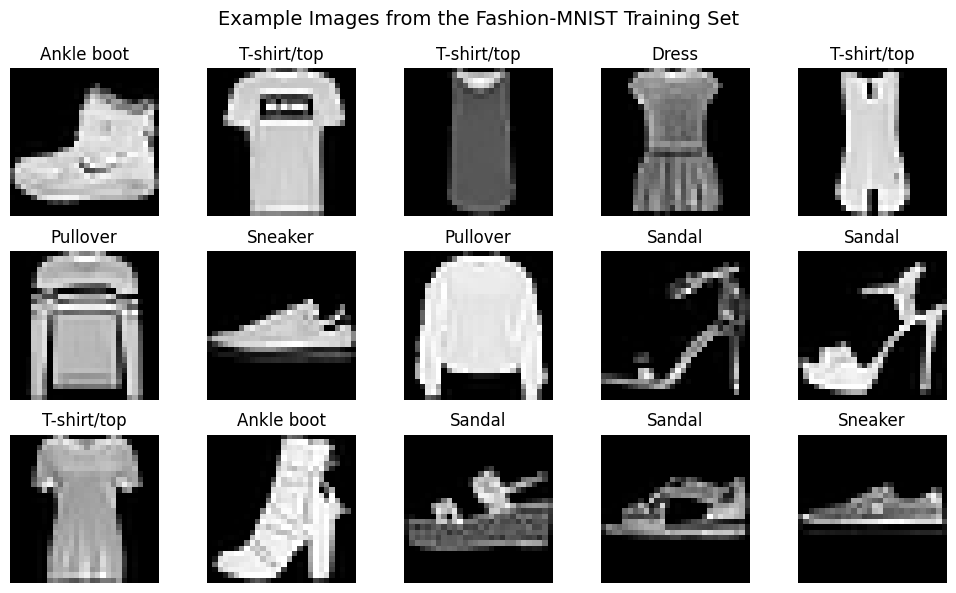

In [7]:
# ============================================================
# Step 7: Visualize example images from Fashion-MNIST
# ============================================================

plt.figure(figsize=(10, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Example Images from the Fashion-MNIST Training Set", fontsize=14)
plt.tight_layout()

# Save figure for report/GitHub
plt.savefig(os.path.join(results_dir, "fashion_mnist_examples.png"), dpi=300, bbox_inches="tight")

plt.show()

In [8]:
# ============================================================
# Step 8: Preprocess the data for CNN and Random Forest
# ============================================================

# Normalize pixel values from 0-255 to 0-1
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

# CNN input: reshape to include the channel dimension
# Fashion-MNIST images are grayscale, so the channel number is 1
x_train_cnn = x_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_norm.reshape(-1, 28, 28, 1)

# Convert labels to one-hot encoding for CNN
y_train_cnn = to_categorical(y_train, num_classes=10)
y_test_cnn = to_categorical(y_test, num_classes=10)

# Random Forest input: flatten each 28x28 image into 784 pixel features
x_train_rf = x_train_norm.reshape(x_train_norm.shape[0], -1)
x_test_rf = x_test_norm.reshape(x_test_norm.shape[0], -1)

print("CNN training input shape:", x_train_cnn.shape)
print("CNN test input shape:", x_test_cnn.shape)
print("CNN training labels shape:", y_train_cnn.shape)
print("CNN test labels shape:", y_test_cnn.shape)

print("Random Forest training input shape:", x_train_rf.shape)
print("Random Forest test input shape:", x_test_rf.shape)

CNN training input shape: (60000, 28, 28, 1)
CNN test input shape: (10000, 28, 28, 1)
CNN training labels shape: (60000, 10)
CNN test labels shape: (10000, 10)
Random Forest training input shape: (60000, 784)
Random Forest test input shape: (10000, 784)


In [9]:
# ============================================================
# Step 9: Build the Convolutional Neural Network (CNN)
# ============================================================

cnn_model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

/opt/anaconda3/envs/fashionmnist/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ============================================================
# Step 10: Train the CNN model and measure training time
# ============================================================

cnn_start_time = time.time()

cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train_cnn,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

cnn_training_time = time.time() - cnn_start_time

print(f"CNN training time: {cnn_training_time:.2f} seconds")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7794 - loss: 0.6113 - val_accuracy: 0.8570 - val_loss: 0.3894
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8587 - loss: 0.3861 - val_accuracy: 0.8742 - val_loss: 0.3384
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8777 - loss: 0.3365 - val_accuracy: 0.8858 - val_loss: 0.3031
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8890 - loss: 0.3044 - val_accuracy: 0.8900 - val_loss: 0.2933
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8978 - loss: 0.2816 - val_accuracy: 0.9005 - val_loss: 0.2679
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9036 - loss: 0.2633 - val_accuracy: 0.9062 - val_loss: 0.2600
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9105 - loss: 0.2444 - val_accuracy: 0.9067 - val_loss: 0.2543
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9156 - loss: 0.2294 - va

In [11]:
# ============================================================
# Step 11: Evaluate CNN on training and test sets
# ============================================================

cnn_train_loss, cnn_train_accuracy = cnn_model.evaluate(
    x_train_cnn, y_train_cnn, verbose=0
)

cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    x_test_cnn, y_test_cnn, verbose=0
)

print(f"CNN training accuracy: {cnn_train_accuracy:.4f}")
print(f"CNN training loss: {cnn_train_loss:.4f}")

print(f"CNN test accuracy: {cnn_test_accuracy:.4f}")
print(f"CNN test loss: {cnn_test_loss:.4f}")

CNN training accuracy: 0.9374
CNN training loss: 0.1717
CNN test accuracy: 0.9112
CNN test loss: 0.2504


In [12]:
# ============================================================
# Step 12: Generate CNN predictions
# ============================================================

# Predicted probabilities
cnn_train_pred_probs = cnn_model.predict(x_train_cnn, verbose=0)
cnn_test_pred_probs = cnn_model.predict(x_test_cnn, verbose=0)

# Convert probabilities to class labels
cnn_train_pred = np.argmax(cnn_train_pred_probs, axis=1)
cnn_test_pred = np.argmax(cnn_test_pred_probs, axis=1)

print("CNN predictions generated successfully.")
print("Example predicted labels:", cnn_test_pred[:10])
print("Example true labels:", y_test[:10])

CNN predictions generated successfully.
Example predicted labels: [9 2 1 1 6 1 4 6 5 7]
Example true labels: [9 2 1 1 6 1 4 6 5 7]


In [13]:
# ============================================================
# Step 13: Create CNN confusion matrices for train and test sets
# ============================================================

cnn_train_cm = confusion_matrix(y_train, cnn_train_pred)
cnn_test_cm = confusion_matrix(y_test, cnn_test_pred)

print("CNN training confusion matrix shape:", cnn_train_cm.shape)
print("CNN test confusion matrix shape:", cnn_test_cm.shape)

CNN training confusion matrix shape: (10, 10)
CNN test confusion matrix shape: (10, 10)


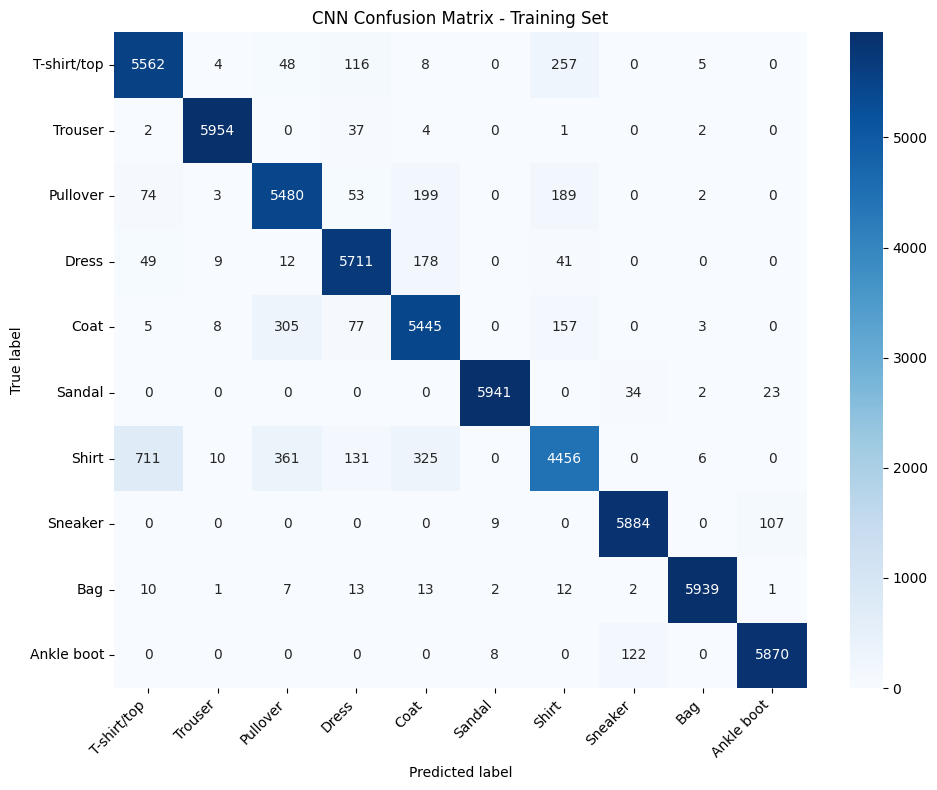

Saved figure: results/cnn_train_confusion_matrix.png


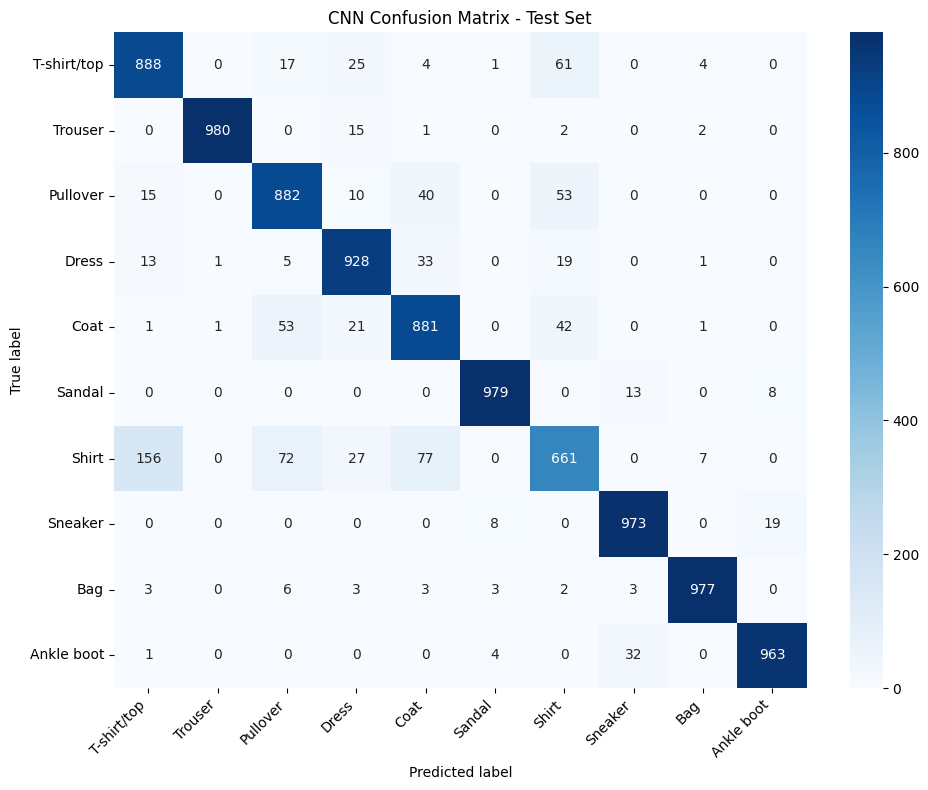

Saved figure: results/cnn_test_confusion_matrix.png


In [14]:
# ============================================================
# Step 14: Plot and save CNN confusion matrices
# ============================================================

def plot_confusion_matrix(cm, title, filename):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    filepath = os.path.join(results_dir, filename)
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Saved figure: {filepath}")

plot_confusion_matrix(
    cnn_train_cm,
    "CNN Confusion Matrix - Training Set",
    "cnn_train_confusion_matrix.png"
)

plot_confusion_matrix(
    cnn_test_cm,
    "CNN Confusion Matrix - Test Set",
    "cnn_test_confusion_matrix.png"
)

In [15]:
# ============================================================
# Step 15: CNN precision and recall for train and test sets
# ============================================================

cnn_train_report = classification_report(
    y_train,
    cnn_train_pred,
    target_names=class_names,
    output_dict=True
)

cnn_test_report = classification_report(
    y_test,
    cnn_test_pred,
    target_names=class_names,
    output_dict=True
)

cnn_metrics_rows = []

for class_name in class_names:
    cnn_metrics_rows.append({
        "Model": "CNN",
        "Dataset": "Training",
        "Class": class_name,
        "Precision": cnn_train_report[class_name]["precision"],
        "Recall": cnn_train_report[class_name]["recall"],
        "F1-score": cnn_train_report[class_name]["f1-score"]
    })
    
for class_name in class_names:
    cnn_metrics_rows.append({
        "Model": "CNN",
        "Dataset": "Test",
        "Class": class_name,
        "Precision": cnn_test_report[class_name]["precision"],
        "Recall": cnn_test_report[class_name]["recall"],
        "F1-score": cnn_test_report[class_name]["f1-score"]
    })

cnn_metrics_df = pd.DataFrame(cnn_metrics_rows)

# Round values for easier reading
cnn_metrics_df[["Precision", "Recall", "F1-score"]] = cnn_metrics_df[
    ["Precision", "Recall", "F1-score"]
].round(4)

cnn_metrics_df

,Model,Dataset,Class,Precision,Recall,F1-score
0,CNN,Training,T-shirt/top,0.8673,0.9270,0.8962
1,CNN,Training,Trouser,0.9942,0.9923,0.9932
2,CNN,Training,Pullover,0.8820,0.9133,0.8974
3,CNN,Training,Dress,0.9304,0.9518,0.9410
4,CNN,Training,Coat,0.8822,0.9075,0.8947
5,CNN,Training,Sandal,0.9968,0.9902,0.9935
6,CNN,Training,Shirt,0.8715,0.7427,0.8019
7,CNN,Training,Sneaker,0.9738,0.9807,0.9772
8,CNN,Training,Bag,0.9966,0.9898,0.9932
9,CNN,Training,Ankle boot,0.9782,0.9783,0.9783


In [16]:
# ============================================================
# Step 16: Save CNN metrics table
# ============================================================

cnn_metrics_path = os.path.join(results_dir, "cnn_precision_recall_table.csv")
cnn_metrics_df.to_csv(cnn_metrics_path, index=False)

print(f"CNN metrics table saved to: {cnn_metrics_path}")

CNN metrics table saved to: results/cnn_precision_recall_table.csv


In [17]:
# ============================================================
# Step 17: Train the Random Forest classifier and measure training time
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_depth=100,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_start_time = time.time()

rf_model.fit(x_train_rf, y_train)

rf_training_time = time.time() - rf_start_time

print(f"Random Forest training time: {rf_training_time:.2f} seconds")

Random Forest training time: 13.65 seconds


In [18]:
# ============================================================
# Step 18: Generate Random Forest predictions
# ============================================================

rf_train_pred = rf_model.predict(x_train_rf)
rf_test_pred = rf_model.predict(x_test_rf)

print("Random Forest predictions generated successfully.")
print("Example predicted labels:", rf_test_pred[:10])
print("Example true labels:", y_test[:10])

Random Forest predictions generated successfully.
Example predicted labels: [9 2 1 1 6 1 4 6 5 7]
Example true labels: [9 2 1 1 6 1 4 6 5 7]


In [19]:
# ============================================================
# Step 19: Evaluate Random Forest accuracy on train and test sets
# ============================================================

rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
rf_test_accuracy = accuracy_score(y_test, rf_test_pred)

print(f"Random Forest training accuracy: {rf_train_accuracy:.4f}")
print(f"Random Forest test accuracy: {rf_test_accuracy:.4f}")
print(f"Random Forest training time: {rf_training_time:.2f} seconds")

Random Forest training accuracy: 1.0000
Random Forest test accuracy: 0.8753
Random Forest training time: 13.65 seconds


In [20]:
# ============================================================
# Step 20: Create Random Forest confusion matrices for train and test sets
# ============================================================

rf_train_cm = confusion_matrix(y_train, rf_train_pred)
rf_test_cm = confusion_matrix(y_test, rf_test_pred)

print("Random Forest training confusion matrix shape:", rf_train_cm.shape)
print("Random Forest test confusion matrix shape:", rf_test_cm.shape)

Random Forest training confusion matrix shape: (10, 10)
Random Forest test confusion matrix shape: (10, 10)


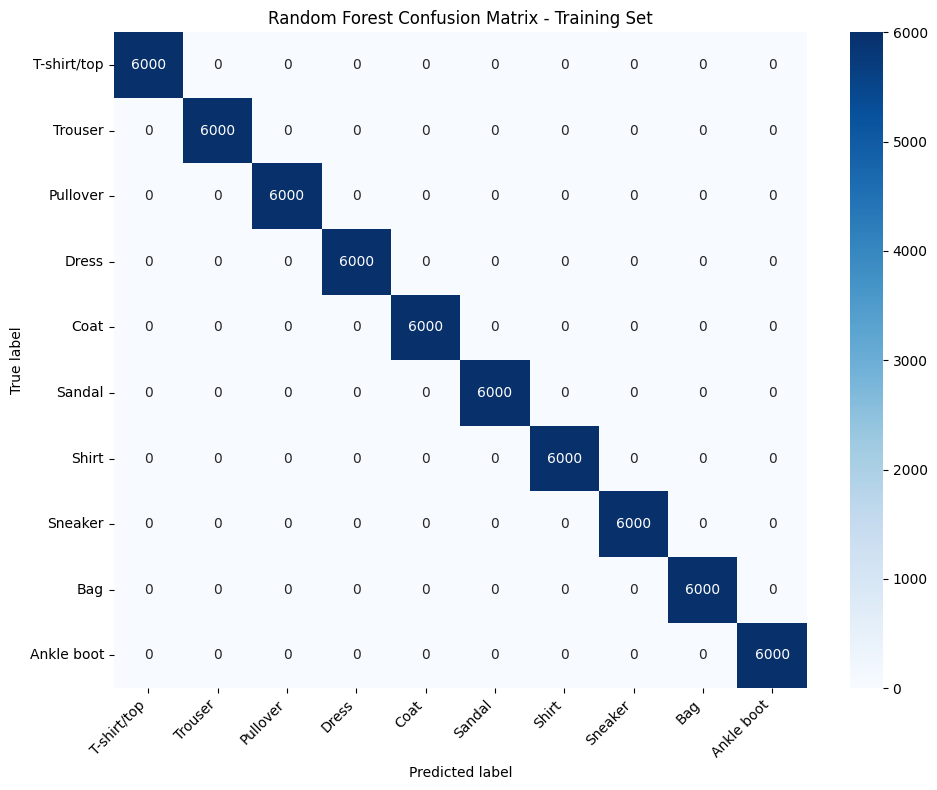

Saved figure: results/rf_train_confusion_matrix.png


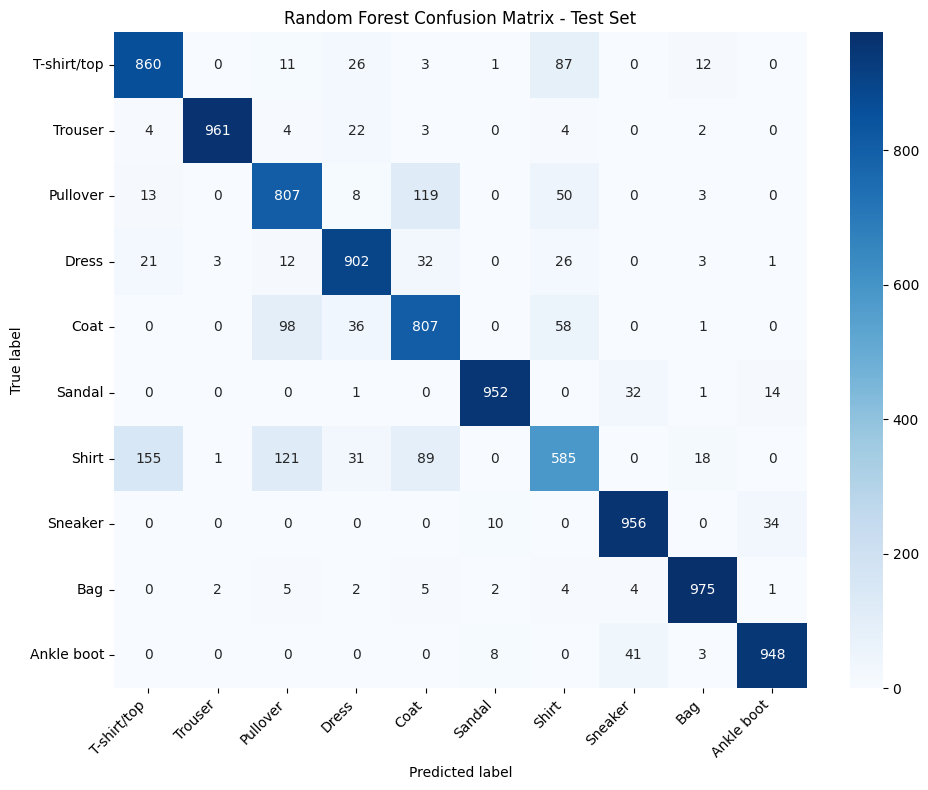

Saved figure: results/rf_test_confusion_matrix.png


In [21]:
# ============================================================
# Step 21: Plot and save Random Forest confusion matrices
# ============================================================

plot_confusion_matrix(
    rf_train_cm,
    "Random Forest Confusion Matrix - Training Set",
    "rf_train_confusion_matrix.png"
)

plot_confusion_matrix(
    rf_test_cm,
    "Random Forest Confusion Matrix - Test Set",
    "rf_test_confusion_matrix.png"
)

In [22]:
# ============================================================
# Step 22: Random Forest precision and recall for train and test sets
# ============================================================

rf_train_report = classification_report(
    y_train,
    rf_train_pred,
    target_names=class_names,
    output_dict=True
)

rf_test_report = classification_report(
    y_test,
    rf_test_pred,
    target_names=class_names,
    output_dict=True
)

rf_metrics_rows = []

for class_name in class_names:
    rf_metrics_rows.append({
        "Model": "Random Forest",
        "Dataset": "Training",
        "Class": class_name,
        "Precision": rf_train_report[class_name]["precision"],
        "Recall": rf_train_report[class_name]["recall"],
        "F1-score": rf_train_report[class_name]["f1-score"]
    })

for class_name in class_names:
    rf_metrics_rows.append({
        "Model": "Random Forest",
        "Dataset": "Test",
        "Class": class_name,
        "Precision": rf_test_report[class_name]["precision"],
        "Recall": rf_test_report[class_name]["recall"],
        "F1-score": rf_test_report[class_name]["f1-score"]
    })

rf_metrics_df = pd.DataFrame(rf_metrics_rows)

# Round values for easier reading
rf_metrics_df[["Precision", "Recall", "F1-score"]] = rf_metrics_df[
    ["Precision", "Recall", "F1-score"]
].round(4)

rf_metrics_df

,Model,Dataset,Class,Precision,Recall,F1-score
0,Random Forest,Training,T-shirt/top,1.0000,1.000,1.0000
1,Random Forest,Training,Trouser,1.0000,1.000,1.0000
2,Random Forest,Training,Pullover,1.0000,1.000,1.0000
3,Random Forest,Training,Dress,1.0000,1.000,1.0000
4,Random Forest,Training,Coat,1.0000,1.000,1.0000
5,Random Forest,Training,Sandal,1.0000,1.000,1.0000
6,Random Forest,Training,Shirt,1.0000,1.000,1.0000
7,Random Forest,Training,Sneaker,1.0000,1.000,1.0000
8,Random Forest,Training,Bag,1.0000,1.000,1.0000
9,Random Forest,Training,Ankle boot,1.0000,1.000,1.0000


In [23]:
# ============================================================
# Step 23: Save Random Forest metrics table
# ============================================================

rf_metrics_path = os.path.join(results_dir, "rf_precision_recall_table.csv")
rf_metrics_df.to_csv(rf_metrics_path, index=False)

print(f"Random Forest metrics table saved to: {rf_metrics_path}")

Random Forest metrics table saved to: results/rf_precision_recall_table.csv


In [24]:
# ============================================================
# Step 24: Create model comparison table
# ============================================================

comparison_df = pd.DataFrame({
    "Model": ["CNN", "Random Forest"],
    "Training Accuracy": [cnn_train_accuracy, rf_train_accuracy],
    "Test Accuracy": [cnn_test_accuracy, rf_test_accuracy],
    "Training Time (seconds)": [cnn_training_time, rf_training_time]
})

comparison_df["Training Accuracy"] = comparison_df["Training Accuracy"].round(4)
comparison_df["Test Accuracy"] = comparison_df["Test Accuracy"].round(4)
comparison_df["Training Time (seconds)"] = comparison_df["Training Time (seconds)"].round(2)

comparison_df

,Model,Training Accuracy,Test Accuracy,Training Time (seconds)
0,CNN,0.9374,0.9112,99.65
1,Random Forest,1.0000,0.8753,13.65


In [25]:
# ============================================================
# Step 25: Save model comparison table
# ============================================================

comparison_path = os.path.join(results_dir, "model_comparison_table.csv")
comparison_df.to_csv(comparison_path, index=False)

print(f"Model comparison table saved to: {comparison_path}")

Model comparison table saved to: results/model_comparison_table.csv


In [26]:
# ============================================================
# Step 26: Identify worst-performing classes using test recall
# ============================================================

cnn_test_metrics = cnn_metrics_df[cnn_metrics_df["Dataset"] == "Test"].copy()
rf_test_metrics = rf_metrics_df[rf_metrics_df["Dataset"] == "Test"].copy()

cnn_worst_classes = cnn_test_metrics.sort_values(by="Recall", ascending=True).head(3)
rf_worst_classes = rf_test_metrics.sort_values(by="Recall", ascending=True).head(3)

print("CNN worst-performing classes based on test recall:")
display(cnn_worst_classes[["Model", "Class", "Precision", "Recall", "F1-score"]])

print("Random Forest worst-performing classes based on test recall:")
display(rf_worst_classes[["Model", "Class", "Precision", "Recall", "F1-score"]])

CNN worst-performing classes based on test recall:


,Model,Class,Precision,Recall,F1-score
16,CNN,Shirt,0.7869,0.661,0.7185
14,CNN,Coat,0.8479,0.881,0.8641
12,CNN,Pullover,0.8522,0.882,0.8668


Random Forest worst-performing classes based on test recall:


,Model,Class,Precision,Recall,F1-score
16,Random Forest,Shirt,0.7187,0.585,0.6450
12,Random Forest,Pullover,0.7628,0.807,0.7843
14,Random Forest,Coat,0.7628,0.807,0.7843


In [27]:
# ============================================================
# Step 27: Save worst-performing class tables
# ============================================================

worst_classes_df = pd.concat([cnn_worst_classes, rf_worst_classes], axis=0)

worst_classes_path = os.path.join(results_dir, "worst_performing_classes.csv")
worst_classes_df.to_csv(worst_classes_path, index=False)

print(f"Worst-performing classes table saved to: {worst_classes_path}")

Worst-performing classes table saved to: results/worst_performing_classes.csv


## Analysis of Worst-Performing Categories

The worst-performing categories were identified using test-set recall, because recall indicates how many true examples of a class were correctly recognized by the model.

For the CNN model, the three weakest categories were Shirt, Pullover, and T-shirt/top. These categories are visually similar because they all represent upper-body garments with overlapping shapes, sleeve structures, and silhouettes. The Shirt class was the most difficult for the CNN, with a recall of 0.7610. This suggests that a considerable number of true Shirt images were misclassified as other visually related clothing categories.

For the Random Forest classifier, the three weakest categories were Shirt, Pullover, and Coat. The Shirt class was again the most problematic category, with a recall of 0.5780. This performance is substantially lower than the CNN result for the same class. A likely explanation is that Random Forest receives the image as a flattened vector of 784 pixel values and therefore does not explicitly learn spatial image patterns such as edges, local textures, and garment shape. In contrast, the CNN uses convolutional filters and pooling operations, which are more suitable for image-based feature extraction.

Overall, the error pattern shows that both classifiers perform better on visually distinctive categories such as footwear or bags, while they perform worse on clothing categories with similar outlines. This supports the recommendation that the CNN is more appropriate for production use in a fashion product classification system.

## Model Comparison and Production Recommendation

The CNN achieved stronger generalization performance than the Random Forest classifier. The Random Forest reached a training accuracy of 1.0000, but its test accuracy was lower, indicating that it memorized the training data more strongly than it generalized to unseen test images. This is a typical sign of overfitting.

The CNN required a longer training time than the Random Forest, but it achieved better test performance and handled image structure more effectively. This is because CNNs are specifically designed for image data: convolutional layers learn local spatial patterns such as edges, shapes, and textures, while pooling layers reduce spatial dimensions and support more robust feature extraction.

In contrast, the Random Forest model used flattened 28 × 28 images as 784 individual pixel features. This representation loses the two-dimensional spatial structure of the image. As a result, Random Forest is less suitable for distinguishing visually similar fashion categories, especially upper-body garments such as Shirt, Pullover, Coat, and T-shirt/top.

For production use in an automated fashion product classification system, the CNN is recommended. Although it requires more training time, it provides better test-set performance and is more appropriate for image classification. The Random Forest can still be useful as a baseline model because it is simpler and faster to train, but the CNN is the better final choice for deployment.

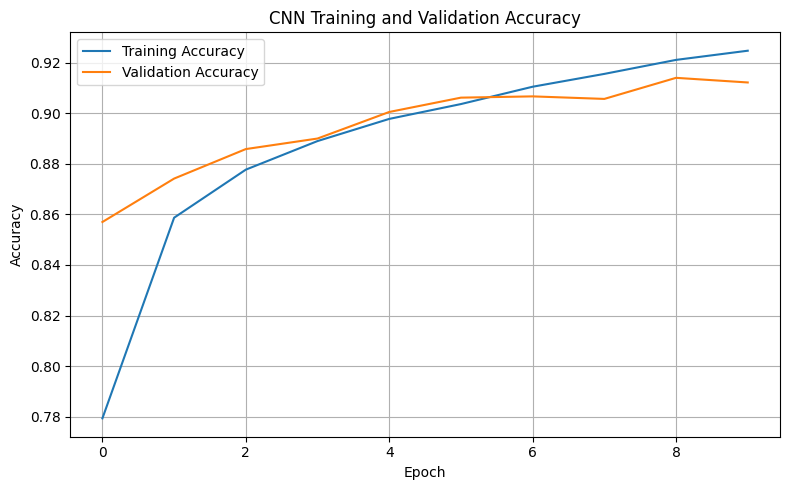

Saved accuracy plot: results/cnn_training_validation_accuracy.png


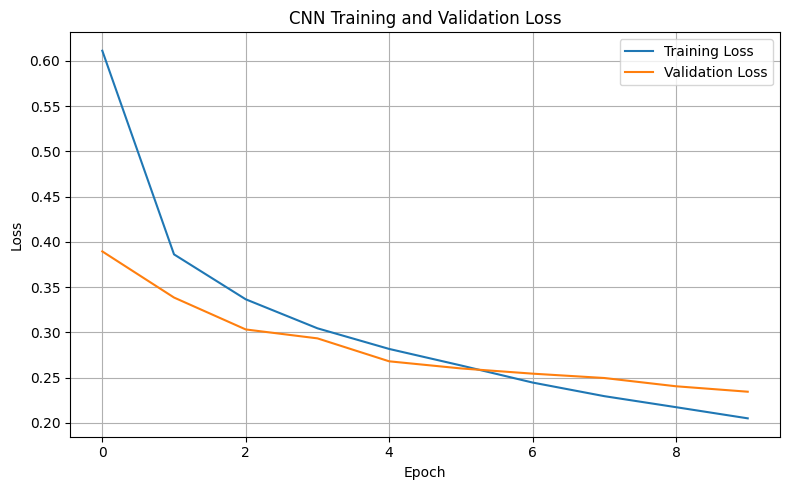

Saved loss plot: results/cnn_training_validation_loss.png


In [28]:
# ============================================================
# Step 31: Plot CNN training and validation accuracy/loss
# ============================================================

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(cnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_plot_path = os.path.join(results_dir, "cnn_training_validation_accuracy.png")
plt.savefig(accuracy_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved accuracy plot: {accuracy_plot_path}")

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(cnn_history.history["loss"], label="Training Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")
plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = os.path.join(results_dir, "cnn_training_validation_loss.png")
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved loss plot: {loss_plot_path}")

In [29]:
# ============================================================
# Step 32: Final summary of main project results
# ============================================================

final_summary = pd.DataFrame({
    "Criterion": [
        "Training accuracy",
        "Test accuracy",
        "Training time (seconds)",
        "Worst test class by recall",
        "Recommended for production"
    ],
    "CNN": [
        round(cnn_train_accuracy, 4),
        round(cnn_test_accuracy, 4),
        round(cnn_training_time, 2),
        cnn_worst_classes.iloc[0]["Class"],
        "Yes"
    ],
    "Random Forest": [
        round(rf_train_accuracy, 4),
        round(rf_test_accuracy, 4),
        round(rf_training_time, 2),
        rf_worst_classes.iloc[0]["Class"],
        "No"
    ]
})

final_summary

,Criterion,CNN,Random Forest
0,Training accuracy,0.9374,1.0
1,Test accuracy,0.9112,0.8753
2,Training time (seconds),99.65,13.65
3,Worst test class by recall,Shirt,Shirt
4,Recommended for production,Yes,No


In [30]:
# ============================================================
# Step 33: Save final summary table
# ============================================================

final_summary_path = os.path.join(results_dir, "final_project_summary.csv")
final_summary.to_csv(final_summary_path, index=False)

print(f"Final summary table saved to: {final_summary_path}")

Final summary table saved to: results/final_project_summary.csv


## Conclusion

This project compared a Convolutional Neural Network and a Random Forest classifier for Fashion-MNIST product classification. Both models were trained and evaluated using the same training and test partitions of the dataset. The evaluation included training accuracy, test accuracy, training time, confusion matrices, and class-level precision and recall.

The results showed that the CNN achieved better generalization performance on the test set, while the Random Forest classifier reached perfect training accuracy but lower test accuracy. This indicates that the Random Forest model overfitted the training data more strongly. The weakest categories for both models were mainly visually similar upper-body garments, especially Shirt, Pullover, Coat, and T-shirt/top.

Based on the evaluation, the CNN is recommended for production use in a fashion retail image-classification scenario. Although it required more training time, it was better suited to image data because it learned spatial features directly from the 28 × 28 pixel images. The Random Forest classifier was useful as a baseline model, but it was less suitable as the final production model because it relied on flattened pixel vectors and did not preserve spatial image structure.

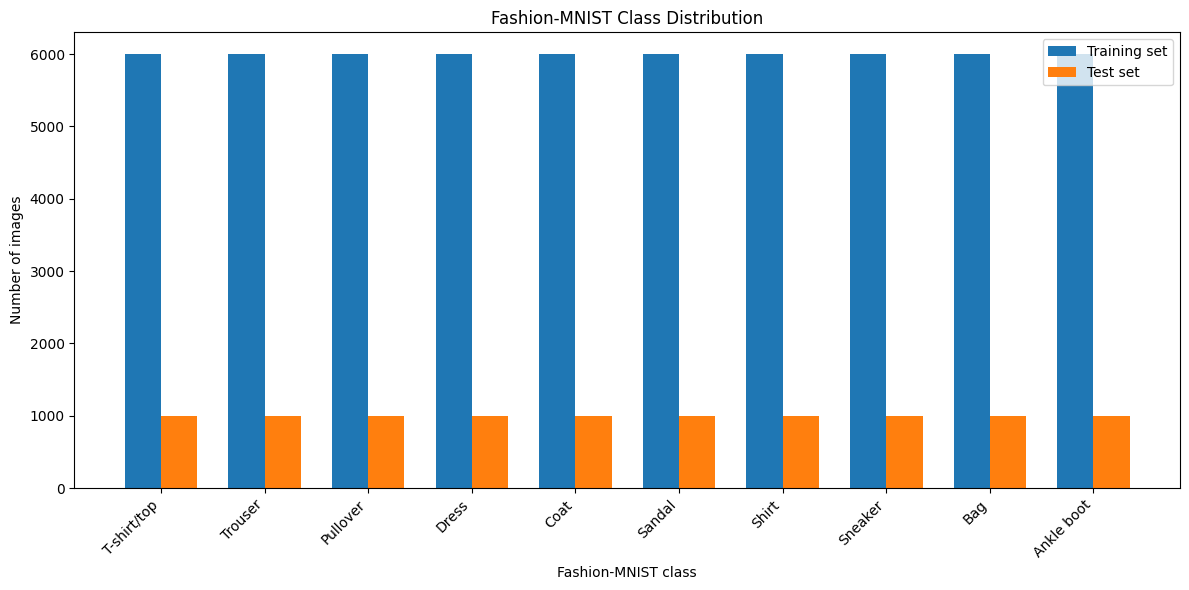

Figure saved as fashion_mnist_class_distribution.png


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load Fashion-MNIST labels
(_, y_train), (_, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Count images in each class
train_counts = np.bincount(y_train, minlength=10)
test_counts = np.bincount(y_test, minlength=10)

x = np.arange(len(class_names))
bar_width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - bar_width / 2,
    train_counts,
    bar_width,
    label="Training set"
)

plt.bar(
    x + bar_width / 2,
    test_counts,
    bar_width,
    label="Test set"
)

plt.xticks(x, class_names, rotation=45, ha="right")
plt.xlabel("Fashion-MNIST class")
plt.ylabel("Number of images")
plt.title("Fashion-MNIST Class Distribution")
plt.legend()
plt.tight_layout()

plt.savefig(
    "fashion_mnist_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved as fashion_mnist_class_distribution.png")

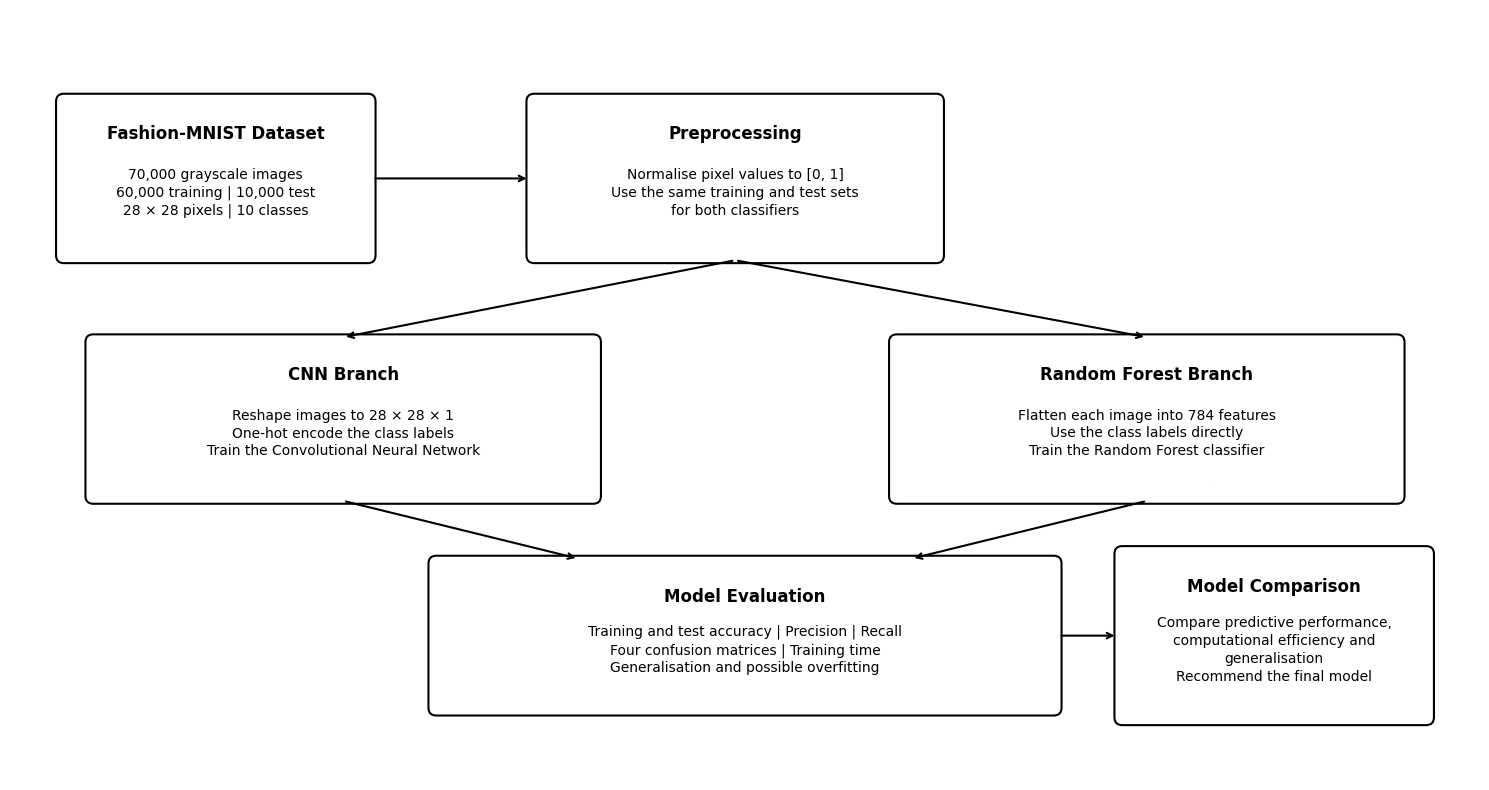

In [32]:
# Figure 3: Methodology flowchart

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Create the figure
fig, ax = plt.subplots(figsize=(15, 8))

ax.set_xlim(0, 15)
ax.set_ylim(0, 8)
ax.axis("off")


# Function for drawing each box
def add_box(x, y, width, height, title, body):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        fill=False,
        linewidth=1.5
    )

    ax.add_patch(box)

    ax.text(
        x + width / 2,
        y + height - 0.30,
        title,
        ha="center",
        va="top",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        x + width / 2,
        y + height / 2 - 0.15,
        body,
        ha="center",
        va="center",
        fontsize=10,
        linespacing=1.35
    )


# Function for drawing arrows
def add_arrow(start, end):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1.5
        }
    )


# Dataset box
add_box(
    0.5, 5.4, 3.2, 1.7,
    "Fashion-MNIST Dataset",
    "70,000 grayscale images\n"
    "60,000 training | 10,000 test\n"
    "28 × 28 pixels | 10 classes"
)

# Preprocessing box
add_box(
    5.3, 5.4, 4.2, 1.7,
    "Preprocessing",
    "Normalise pixel values to [0, 1]\n"
    "Use the same training and test sets\n"
    "for both classifiers"
)

# CNN branch
add_box(
    0.8, 2.9, 5.2, 1.7,
    "CNN Branch",
    "Reshape images to 28 × 28 × 1\n"
    "One-hot encode the class labels\n"
    "Train the Convolutional Neural Network"
)

# Random Forest branch
add_box(
    9.0, 2.9, 5.2, 1.7,
    "Random Forest Branch",
    "Flatten each image into 784 features\n"
    "Use the class labels directly\n"
    "Train the Random Forest classifier"
)

# Evaluation box
add_box(
    4.3, 0.7, 6.4, 1.6,
    "Model Evaluation",
    "Training and test accuracy | Precision | Recall\n"
    "Four confusion matrices | Training time\n"
    "Generalisation and possible overfitting"
)

# Comparison box
add_box(
    11.3, 0.6, 3.2, 1.8,
    "Model Comparison",
    "Compare predictive performance,\n"
    "computational efficiency and\n"
    "generalisation\n"
    "Recommend the final model"
)

# Arrows
add_arrow((3.7, 6.25), (5.3, 6.25))

add_arrow((7.4, 5.4), (3.4, 4.6))
add_arrow((7.4, 5.4), (11.6, 4.6))

add_arrow((3.4, 2.9), (5.8, 2.3))
add_arrow((11.6, 2.9), (9.2, 2.3))

add_arrow((10.7, 1.5), (11.3, 1.5))

# Save the graph
plt.tight_layout()

plt.savefig(
    "methodology_flowchart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

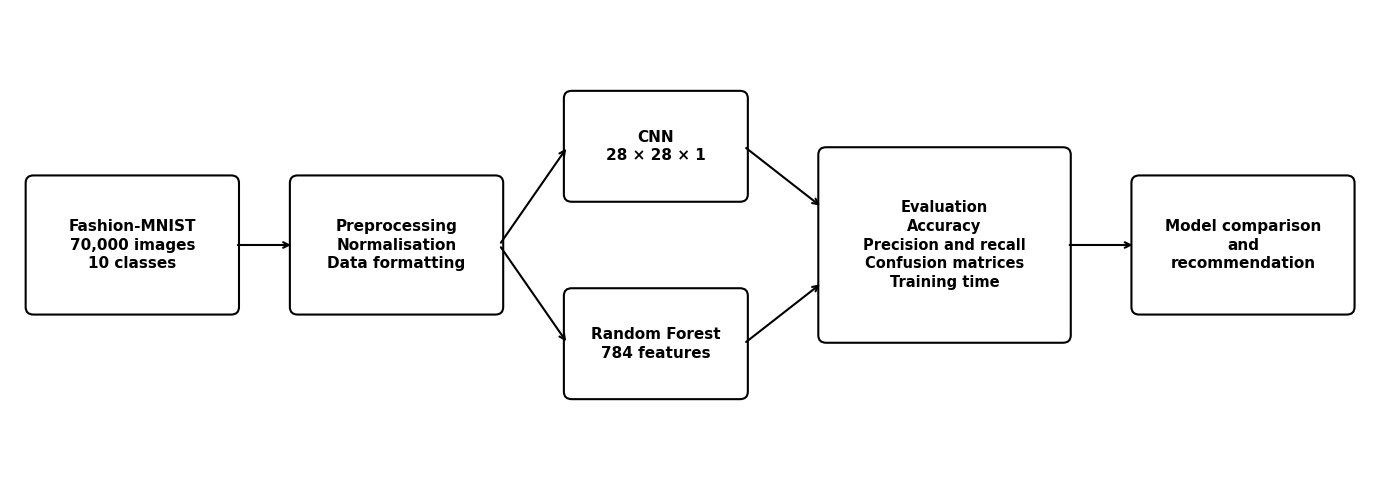

In [33]:
# Figure 3: Simplified methodology flowchart

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis("off")


def add_box(x, y, width, height, text, fontsize=11):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.04,rounding_size=0.08",
        fill=False,
        linewidth=1.5
    )
    ax.add_patch(box)

    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold",
        linespacing=1.3
    )


def add_arrow(start, end):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1.5
        }
    )


# Main boxes
add_box(
    0.2, 1.8, 2.1, 1.4,
    "Fashion-MNIST\n70,000 images\n10 classes"
)

add_box(
    2.9, 1.8, 2.1, 1.4,
    "Preprocessing\nNormalisation\nData formatting"
)

add_box(
    5.7, 3.0, 1.8, 1.1,
    "CNN\n28 × 28 × 1"
)

add_box(
    5.7, 0.9, 1.8, 1.1,
    "Random Forest\n784 features"
)

add_box(
    8.3, 1.5, 2.5, 2.0,
    "Evaluation\nAccuracy\nPrecision and recall\nConfusion matrices\nTraining time",
    fontsize=10.5
)

add_box(
    11.5, 1.8, 2.2, 1.4,
    "Model comparison\nand\nrecommendation"
)

# Arrows
add_arrow((2.3, 2.5), (2.9, 2.5))

add_arrow((5.0, 2.5), (5.7, 3.55))
add_arrow((5.0, 2.5), (5.7, 1.45))

add_arrow((7.5, 3.55), (8.3, 2.9))
add_arrow((7.5, 1.45), (8.3, 2.1))

add_arrow((10.8, 2.5), (11.5, 2.5))

plt.tight_layout()

plt.savefig(
    "methodology_flowchart_simple.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

In [34]:
# ============================================================
# FINAL RANDOM FOREST RE-RUN
# Xiao et al. configuration
# ============================================================

import time
import numpy as np

from tensorflow.keras.datasets import fashion_mnist
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load Fashion-MNIST again
(x_train_final, y_train_final), (x_test_final, y_test_final) = fashion_mnist.load_data()

# 2. Normalise pixel values to 0–1
x_train_final = x_train_final.astype("float32") / 255.0
x_test_final = x_test_final.astype("float32") / 255.0

# 3. Flatten 28 × 28 images into 784 features
x_train_rf_final = x_train_final.reshape(x_train_final.shape[0], -1)
x_test_rf_final = x_test_final.reshape(x_test_final.shape[0], -1)

# 4. Create the revised Random Forest
rf_final = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_depth=100,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# 5. Train and measure training time
start_time = time.time()

rf_final.fit(x_train_rf_final, y_train_final)

rf_final_training_time = time.time() - start_time

# 6. Predictions
rf_final_train_pred = rf_final.predict(x_train_rf_final)
rf_final_test_pred = rf_final.predict(x_test_rf_final)

# 7. Accuracy
rf_final_train_accuracy = accuracy_score(
    y_train_final,
    rf_final_train_pred
)

rf_final_test_accuracy = accuracy_score(
    y_test_final,
    rf_final_test_pred
)

# 8. Display results
print("FINAL RANDOM FOREST RESULTS")
print("---------------------------")
print(f"Training accuracy: {rf_final_train_accuracy:.4f}")
print(f"Test accuracy:     {rf_final_test_accuracy:.4f}")
print(f"Training time:     {rf_final_training_time:.2f} seconds")

print("\nSelected parameters:")
print("n_estimators =", rf_final.n_estimators)
print("criterion    =", rf_final.criterion)
print("max_depth    =", rf_final.max_depth)
print("max_features =", rf_final.max_features)
print("random_state =", rf_final.random_state)
print("n_jobs       =", rf_final.n_jobs)

FINAL RANDOM FOREST RESULTS
---------------------------
Training accuracy: 1.0000
Test accuracy:     0.8753
Training time:     13.65 seconds

Selected parameters:
n_estimators = 100
criterion    = entropy
max_depth    = 100
max_features = sqrt
random_state = 42
n_jobs       = -1


In [35]:
# ============================================================
# FINAL RANDOM FOREST PRECISION AND RECALL
# ============================================================

import pandas as pd
from sklearn.metrics import classification_report

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Classification reports
rf_final_train_report = classification_report(
    y_train_final,
    rf_final_train_pred,
    target_names=class_names,
    output_dict=True
)

rf_final_test_report = classification_report(
    y_test_final,
    rf_final_test_pred,
    target_names=class_names,
    output_dict=True
)

# Build one table
rows = []

for class_name in class_names:
    rows.append({
        "Class": class_name,
        "Train Precision": rf_final_train_report[class_name]["precision"],
        "Train Recall": rf_final_train_report[class_name]["recall"],
        "Test Precision": rf_final_test_report[class_name]["precision"],
        "Test Recall": rf_final_test_report[class_name]["recall"]
    })

rf_final_metrics_df = pd.DataFrame(rows)

# Round for report
rf_final_metrics_df = rf_final_metrics_df.round(4)

print(rf_final_metrics_df.to_string(index=False))

      Class  Train Precision  Train Recall  Test Precision  Test Recall
T-shirt/top              1.0           1.0          0.8167        0.860
    Trouser              1.0           1.0          0.9938        0.961
   Pullover              1.0           1.0          0.7628        0.807
      Dress              1.0           1.0          0.8774        0.902
       Coat              1.0           1.0          0.7628        0.807
     Sandal              1.0           1.0          0.9784        0.952
      Shirt              1.0           1.0          0.7187        0.585
    Sneaker              1.0           1.0          0.9255        0.956
        Bag              1.0           1.0          0.9578        0.975
 Ankle boot              1.0           1.0          0.9499        0.948


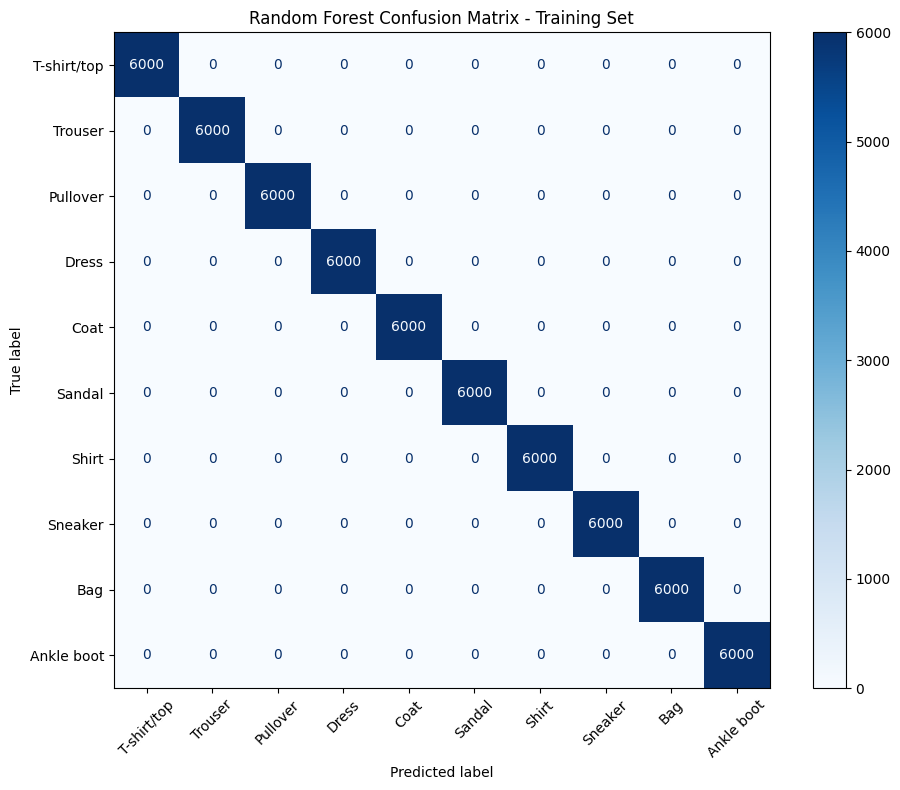

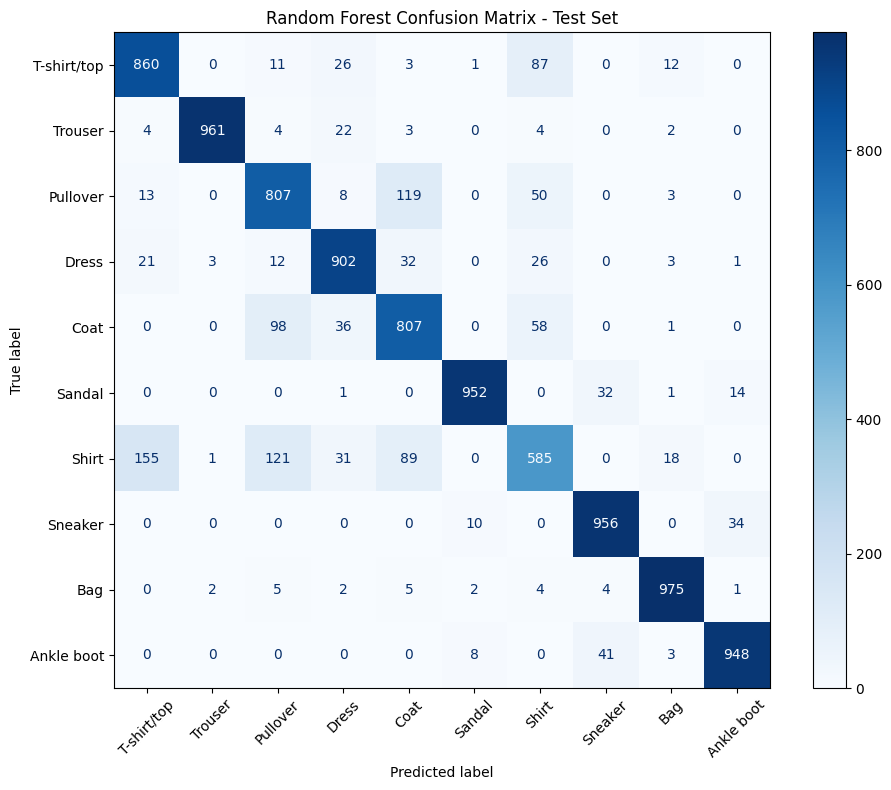

Saved:
results/rf_final_train_confusion_matrix.png
results/rf_final_test_confusion_matrix.png


In [36]:
# ============================================================
# FINAL RANDOM FOREST CONFUSION MATRICES
# ============================================================

import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create results folder if it does not already exist
os.makedirs("results", exist_ok=True)

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# ----------------------------
# TRAINING confusion matrix
# ----------------------------

rf_final_train_cm = confusion_matrix(
    y_train_final,
    rf_final_train_pred
)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_final_train_cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45,
    colorbar=True
)

ax.set_title("Random Forest Confusion Matrix - Training Set")

plt.tight_layout()

plt.savefig(
    "results/rf_final_train_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ----------------------------
# TEST confusion matrix
# ----------------------------

rf_final_test_cm = confusion_matrix(
    y_test_final,
    rf_final_test_pred
)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_final_test_cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45,
    colorbar=True
)

ax.set_title("Random Forest Confusion Matrix - Test Set")

plt.tight_layout()

plt.savefig(
    "results/rf_final_test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("results/rf_final_train_confusion_matrix.png")
print("results/rf_final_test_confusion_matrix.png")

In [37]:
import os

print("Current folder:")
print(os.getcwd())

print("\nNew training matrix:")
print(os.path.abspath("results/rf_final_train_confusion_matrix.png"))
print("Exists:", os.path.exists("results/rf_final_train_confusion_matrix.png"))

print("\nNew test matrix:")
print(os.path.abspath("results/rf_final_test_confusion_matrix.png"))
print("Exists:", os.path.exists("results/rf_final_test_confusion_matrix.png"))

Current folder:
/Users/aydan/Fashion_MNIST_Task2_Project

New training matrix:
/Users/aydan/Fashion_MNIST_Task2_Project/results/rf_final_train_confusion_matrix.png
Exists: True

New test matrix:
/Users/aydan/Fashion_MNIST_Task2_Project/results/rf_final_test_confusion_matrix.png
Exists: True


In [38]:
from IPython.display import FileLink

FileLink("results/rf_final_train_confusion_matrix.png")

/Users/aydan/Fashion_MNIST_Task2_Project/results/rf_final_train_confusion_matrix.png

In [39]:
from IPython.display import FileLink

FileLink("results/rf_final_test_confusion_matrix.png")

/Users/aydan/Fashion_MNIST_Task2_Project/results/rf_final_test_confusion_matrix.png